In [1]:
import torch
import matplotlib.pyplot as plt

In [2]:
with open("encoded/v3.1_autoencoder_clean.pt", "rb") as f:
    encodings_clean = torch.load(f).to("cpu")
encodings_clean.shape

torch.Size([16, 200])

In [3]:
autoencoder = torch.load("models/autoencoder.pt", weights_only=False).to("cpu")
autoencoder.eval()

Autoencoder(
  (encoder): Encoder(
    (encoder): Sequential(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (3): ReLU()
      (4): Flatten(start_dim=1, end_dim=-1)
      (5): Linear(in_features=165888, out_features=200, bias=True)
      (6): ReLU()
    )
  )
  (decoder): Decoder(
    (decoder): Sequential(
      (0): Linear(in_features=200, out_features=165888, bias=True)
      (1): ReLU()
      (2): Unflatten(dim=1, unflattened_size=(32, 54, 96))
      (3): ConvTranspose2d(32, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
      (4): ReLU()
      (5): ConvTranspose2d(16, 3, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
      (6): Sigmoid()
    )
  )
)

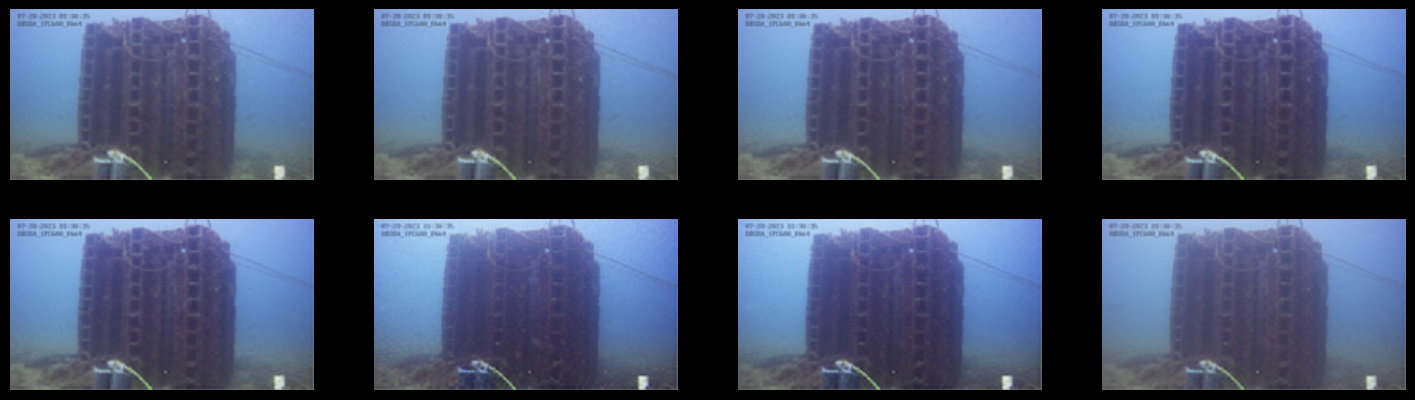

In [4]:
decoded = autoencoder.decoder(encodings_clean[:20])

fig, axes = plt.subplots(2, 4, figsize=(18, 5))
for image, ax in zip(decoded, axes.flatten()):
    img = image.permute(1, 2, 0).detach().numpy()
    ax.imshow(img, cmap="gray")
    ax.axis("off")

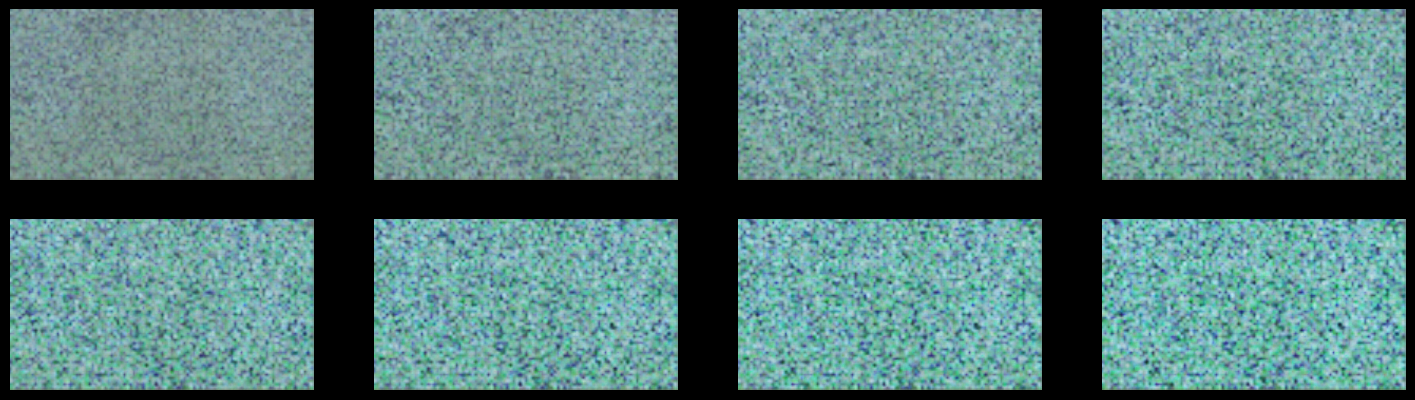

In [5]:
encoding = torch.zeros(1, encodings_clean.shape[1]).to("cpu")

fig, axes = plt.subplots(2, 4, figsize=(18, 5))
for i, ax in enumerate(axes.flatten()):
    encoding[0, i] = 10.0  # Set a feature to a high value
    decoded = autoencoder.decoder(encoding)[0]
    img = decoded.permute(1, 2, 0).detach().numpy()
    ax.imshow(img, cmap="gray")
    ax.axis("off")